**Autor**: Juan Alejandro Carrillo Jaimes

**Creación**: 05-08-2026

**Ult Modificación**: 09-08-2026

**Materia**: Mét. Apren Auto para Toma de Decisiones 20262  - A

**Descripción**: Notebook de aprendizaje supervisado sobre el dataset Adult (Census Income). Se realiza entendimiento de datos (EDA), preparación (imputación, codificación, normalización, balanceo) y modelado con regresión logística y árbol de decisión, comparando resultados bajo distintas configuraciones de atributos y particiones.

---

Profe, este notebook tiene esta estructura, porque es la que utilizo normalmente para mis notebooks de machine learning, siguiendo el flujo estándar de un proyecto de aprendizaje supervisado:

1. **EDA**: entendimiento inicial del conjunto de datos (dimensiones, tipos de
   dato, medidas de tendencia central y dispersión, correlaciones, y detección
   de faltantes, atípicos y desbalance de clases), sin modificar los datos.
2. **Preprocesamiento**: corrección de los problemas detectados en el EDA
   (imputación de faltantes) y eliminación de atributos según lo requerido.
3. **Transformación y Normalización**: codificación de atributos categóricos,
   normalización de atributos numéricos y balanceo de clases.
4. **Modelado**: partición de los datos en entrenamiento/prueba y entrenamiento
   del modelo de clasificación.
5. **Evaluación**: cálculo de métricas de desempeño sobre el conjunto de prueba.

Al final se presenta la actividad propuesta por el docente (modificación de
atributos, técnica y partición) junto con la comparación de resultados y las
respuestas a las preguntas planteadas.

In [1]:
# Carga de librerías y lectura del archivo que contiene los datos

import numpy as np
import pandas as pd
import sklearn as sk
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Semilla para reproducibilidad
RANDOM_STATE = 42

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
df = pd.read_csv(url, header=None, na_values=" ?")

# Se etiquetan las columnas para poder interpretar más fácilmente los datos.
# Cada fila es un ejemplo, cada columna un atributo.
# La columna llamada C es el atributo a predecir
df.columns = ['Age', 'Workclass', 'Fnlwgt', 'Education', 'Education-num', 'Marital-status', 'Occupation',
              'Relationship', 'Race', 'Sex', 'Capital-gain', 'Capital-loss', 'Hpw', 'Country', 'C']
df.head()

,Age,Workclass,Fnlwgt,Education,Education-num,Marital-status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hpw,Country,C
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## EDA

### Code Functions

In [3]:
def get_dimensions_summary(df: pd.DataFrame) -> None:
    """Imprime la cantidad de registros, atributos y sus tipos de dato.

    Args:
        df (pd.DataFrame): Conjunto de datos a inspeccionar.
    """
    print(f"Cantidad de registros: {df.shape[0]}")
    print(f"Cantidad de atributos: {df.shape[1]}")
    print("\nTipos de dato por atributo:")
    print(df.dtypes)

In [4]:
def get_central_tendency(df: pd.DataFrame) -> pd.DataFrame:
    """Calcula media y mediana para atributos numéricos,
    y la moda para atributos numéricos y categóricos.

    Args:
        df (pd.DataFrame): Conjunto de datos a analizar.

    Returns:
        pd.DataFrame: Tabla resumen con las medidas de tendencia central.
    """
    numeric_cols = df.select_dtypes(include=np.number)
    summary = numeric_cols.agg(["mean", "median"]).T
    summary["mode"] = numeric_cols.mode().iloc[0]

    categorical_cols = df.select_dtypes(exclude=np.number)
    categorical_summary = pd.DataFrame({"mode": categorical_cols.mode().iloc[0]})

    return pd.concat([summary, categorical_summary], axis=0)

In [5]:
def get_dispersion(df: pd.DataFrame) -> pd.DataFrame:
    """Calcula desviación estándar, varianza y rango para los
    atributos numéricos donde tenga sentido.

    Args:
        df (pd.DataFrame): Conjunto de datos a analizar.

    Returns:
        pd.DataFrame: Tabla con std, var y range por atributo numérico.
    """
    numeric_cols = df.select_dtypes(include=np.number)
    dispersion = pd.DataFrame({
        "std": numeric_cols.std(),
        "var": numeric_cols.var(),
        "range": numeric_cols.max() - numeric_cols.min(),
    })
    return dispersion

In [6]:
def plot_correlation_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """Calcula y grafica la matriz de correlación de los atributos numéricos.

    Args:
        df (pd.DataFrame): Conjunto de datos a analizar.

    Returns:
        pd.DataFrame: Matriz de correlación.
    """
    corr = df.select_dtypes(include=np.number).corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Matriz de correlación")
    plt.show()

    return corr

In [7]:
def detect_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Detecta valores faltantes por columna y por registro.

    Args:
        df (pd.DataFrame): Conjunto de datos a analizar.

    Returns:
        pd.DataFrame: Cantidad y porcentaje de faltantes por columna.
    """
    missing_per_col = df.isnull().sum()
    percentage = (missing_per_col / len(df)) * 100

    summary = pd.DataFrame({
        "missing": missing_per_col,
        "percentage": percentage,
    })

    # Registros con al menos un dato faltante
    missing_per_row = df.isnull().sum(axis=1)
    print(f"Registros con al menos un faltante: {(missing_per_row > 0).sum()}")

    return summary[summary["missing"] > 0]

In [8]:
def detect_outliers(df: pd.DataFrame, columns: list) -> dict:
    """Detecta valores atípicos usando el método del rango intercuartílico (IQR).

    Args:
        df (pd.DataFrame): Conjunto de datos a analizar.
        columns (list): Lista de columnas numéricas a evaluar.

    Returns:
        dict: Cantidad de atípicos encontrados por columna.
    """
    result = {}
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        result[col] = len(outliers)

    return result

In [9]:
def detect_class_imbalance(df: pd.DataFrame, class_column: str) -> pd.DataFrame:
    """Calcula la distribución de clases para identificar desbalance.

    Args:
        df (pd.DataFrame): Conjunto de datos a analizar.
        class_column (str): Nombre de la columna objetivo (clase).

    Returns:
        pd.DataFrame: Conteo y proporción de cada clase.
    """
    count = df[class_column].value_counts()
    proportion = df[class_column].value_counts(normalize=True) * 100

    return pd.DataFrame({"count": count, "proportion (%)": proportion})

In [17]:
def check_redundancy(df: pd.DataFrame, column_a: str, column_b: str) -> None:
    """Verifica si dos atributos son redundantes comprobando si existe
    una correspondencia biunívoca (1 a 1) entre sus valores.

    Para cada valor único de column_a, revisa cuántos valores distintos
    de column_b le corresponden (y viceversa). Si ambos conteos son
    siempre 1, los atributos son redundantes: uno se puede eliminar
    sin perder información.

    Args:
        df (pd.DataFrame): Conjunto de datos a analizar.
        column_a (str): Nombre del primer atributo.
        column_b (str): Nombre del segundo atributo.

    Returns:
        None: Imprime el resultado del análisis.
    """
    # Cuántos valores distintos de B tiene cada valor de A, y viceversa
    a_to_b = df.groupby(column_a)[column_b].nunique()
    b_to_a = df.groupby(column_b)[column_a].nunique()

    is_a_to_b_unique = (a_to_b == 1).all()
    is_b_to_a_unique = (b_to_a == 1).all()

    print(f"¿Cada valor de '{column_a}' mapea a un único '{column_b}'? {is_a_to_b_unique}")
    print(f"¿Cada valor de '{column_b}' mapea a un único '{column_a}'? {is_b_to_a_unique}")

    if is_a_to_b_unique and is_b_to_a_unique:
        print(f"\n'{column_a}' y '{column_b}' son redundantes (correspondencia 1 a 1).")
    else:
        print(f"\n'{column_a}' y '{column_b}' NO son completamente redundantes.")

    # Tabla de correspondencia, útil para inspección visual
    mapping_table = df.groupby(column_a)[column_b].unique()
    print(f"\nTabla de correspondencia ({column_a} -> {column_b}):")
    print(mapping_table)

### Execution EDA

Cantidad de registros: 32561
Cantidad de atributos: 15

Tipos de dato por atributo:
Age                int64
Workclass         object
Fnlwgt             int64
Education         object
Education-num      int64
Marital-status    object
Occupation        object
Relationship      object
Race              object
Sex               object
Capital-gain       int64
Capital-loss       int64
Hpw                int64
Country           object
C                 object
dtype: object


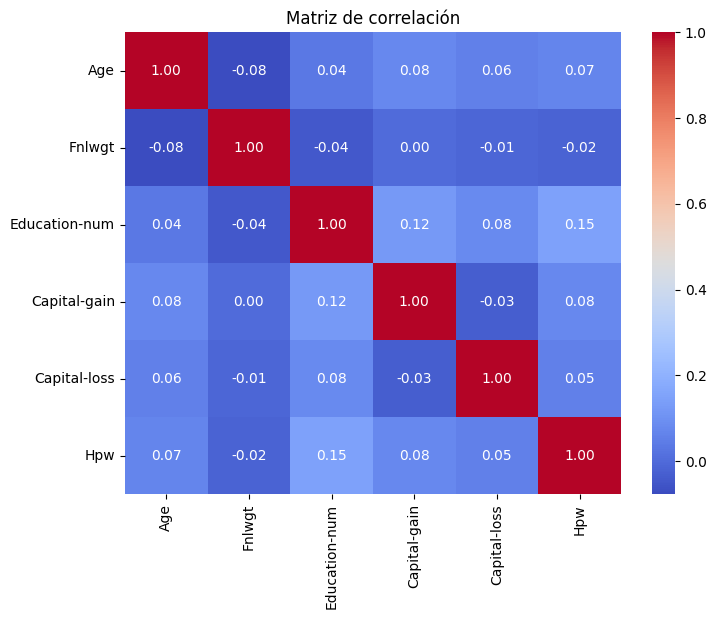

Registros con al menos un faltante: 2399


,count,proportion (%)
C,,
<=50K,24720,75.919044
>50K,7841,24.080956


In [11]:
get_dimensions_summary(df)
get_central_tendency(df)
get_dispersion(df)
plot_correlation_matrix(df)
detect_missing_values(df)
detect_outliers(df, ["Age", "Hpw", "Capital-gain", "Capital-loss"])
detect_class_imbalance(df, "C")

In [18]:
check_redundancy(df, "Education", "Education-num")

¿Cada valor de 'Education' mapea a un único 'Education-num'? True
¿Cada valor de 'Education-num' mapea a un único 'Education'? True

'Education' y 'Education-num' son redundantes (correspondencia 1 a 1).

Tabla de correspondencia (Education -> Education-num):
Education
10th             [6]
11th             [7]
12th             [8]
1st-4th          [2]
5th-6th          [3]
7th-8th          [4]
9th              [5]
Assoc-acdm      [12]
Assoc-voc       [11]
Bachelors       [13]
Doctorate       [16]
HS-grad          [9]
Masters         [14]
Preschool        [1]
Prof-school     [15]
Some-college    [10]
Name: Education-num, dtype: object


## Preprocesamiento

### Code Functions

In [14]:
def impute_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Completa los datos faltantes: media para atributos numéricos
    y moda para atributos categóricos.

    Args:
        df (pd.DataFrame): Conjunto de datos con posibles faltantes.

    Returns:
        pd.DataFrame: Copia del dataframe con los faltantes imputados.
    """
    df_imputed = df.copy()

    for col in df_imputed.columns:
        if df_imputed[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df_imputed[col]):
                df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mean())
            else:
                mode = df_imputed[col].mode().iloc[0]
                df_imputed[col] = df_imputed[col].fillna(mode)

    return df_imputed

In [15]:
def drop_attribute(df: pd.DataFrame, attribute: str) -> pd.DataFrame:
    """Elimina un atributo (columna) del conjunto de datos.

    Args:
        df (pd.DataFrame): Conjunto de datos original.
        attribute (str): Nombre de la columna a eliminar.

    Returns:
        pd.DataFrame: Copia del dataframe sin la columna indicada.
    """
    return df.drop(columns=[attribute])

### Execution Preprocesamiento

In [35]:
data_clean = impute_missing_values(df)
data_clean.shape

(32561, 15)

## Transformación y Normalización

### Code Functions

In [36]:
def encode_categorical(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """Convierte atributos categóricos a escala numérica usando LabelEncoder.

    Args:
        df (pd.DataFrame): Conjunto de datos a transformar.
        columns (list): Lista de columnas categóricas a codificar.

    Returns:
        pd.DataFrame: Copia del dataframe con las columnas codificadas.
    """
    df_encoded = df.copy()
    encoder = LabelEncoder()

    for col in columns:
        df_encoded[col] = encoder.fit_transform(df_encoded[col])

    return df_encoded

In [37]:
def normalize_attributes(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """Normaliza atributos numéricos al rango [0, 1] usando MinMaxScaler.

    Args:
        df (pd.DataFrame): Conjunto de datos a transformar.
        columns (list): Lista de columnas numéricas a normalizar.

    Returns:
        pd.DataFrame: Copia del dataframe con las columnas normalizadas.
    """
    df_normalized = df.copy()
    scaler = MinMaxScaler()

    df_normalized[columns] = scaler.fit_transform(df_normalized[columns])

    return df_normalized

In [38]:
def balance_classes(df: pd.DataFrame, class_column: str) -> pd.DataFrame:
    """Balancea las clases eliminando registros de la clase mayoritaria
    hasta igualar el tamaño de la clase minoritaria (undersampling).

    Args:
        df (pd.DataFrame): Conjunto de datos a balancear.
        class_column (str): Nombre de la columna objetivo (clase).

    Returns:
        pd.DataFrame: Conjunto de datos balanceado.
    """
    count = df[class_column].value_counts()
    minority_class = count.idxmin()
    n_minority = count.min()

    parts = []
    for cls in count.index:
        subset = df[df[class_column] == cls]
        if cls != minority_class:
            subset = subset.sample(n=n_minority, random_state=RANDOM_STATE)
        parts.append(subset)

    return pd.concat(parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

### Execution Transformación y Normalización

In [39]:
categorical_cols = data_clean.select_dtypes(exclude=np.number).columns.tolist()
categorical_cols.remove("C")  # la clase se codifica aparte

numeric_cols = data_clean.select_dtypes(include=np.number).columns.tolist()

data_prep = encode_categorical(data_clean, categorical_cols)
data_prep["C"] = LabelEncoder().fit_transform(data_prep["C"])

# Normalizamos TODAS las columnas de entrada (numéricas originales +
# categóricas ya codificadas), porque LabelEncoder deja escalas distintas
# entre atributos y eso afecta la convergencia de la regresión logística.
all_feature_cols = [col for col in data_prep.columns if col != "C"]
data_prep = normalize_attributes(data_prep, all_feature_cols)

data_prep = balance_classes(data_prep, "C")

## Modelado

### Code Functions

In [40]:
def split_data(X: pd.DataFrame, y: pd.Series, test_size: float = 0.3):
    """Divide el conjunto de datos en entrenamiento y prueba.

    Args:
        X (pd.DataFrame): Atributos de entrada.
        y (pd.Series): Atributo objetivo (clase).
        test_size (float): Proporción del conjunto de prueba.

    Returns:
        tuple: X_train, X_test, y_train, y_test.
    """
    return train_test_split(X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y)

In [41]:
def train_model(model, X_train, y_train):
    """Entrena un modelo de clasificación con el conjunto de entrenamiento.

    Args:
        model: Instancia de un clasificador de scikit-learn.
        X_train (pd.DataFrame): Atributos de entrenamiento.
        y_train (pd.Series): Clase de entrenamiento.

    Returns:
        Modelo entrenado.
    """
    model.fit(X_train, y_train)
    return model

In [48]:
def calculate_metrics(y_test, y_pred) -> dict:
    """Calcula métricas de desempeño para evaluar las predicciones de un modelo.

    Args:
        y_test: Valores reales de la clase.
        y_pred: Valores predichos por el modelo.

    Returns:
        dict: Diccionario con accuracy, precision, recall y f1_score.
    """
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
    }

In [49]:
def compare_models(results: dict) -> pd.DataFrame:
    """Construye una tabla comparativa de métricas entre varios modelos.

    Args:
        results (dict): Diccionario donde cada llave es el nombre del
            modelo y cada valor es el diccionario de métricas.

    Returns:
        pd.DataFrame: Tabla comparativa de desempeño.
    """
    return pd.DataFrame(results).T

In [50]:
def run_pipeline(df: pd.DataFrame, class_column: str, model, test_size: float,
                  attribute_to_drop: str = None) -> dict:
    """Ejecuta el flujo completo de modelado: elimina un atributo opcional,
    divide en entrenamiento/prueba, entrena el modelo y calcula sus métricas.

    Args:
        df (pd.DataFrame): Conjunto de datos ya transformado y normalizado.
        class_column (str): Nombre de la columna objetivo (clase).
        model: Instancia de un clasificador de scikit-learn, sin entrenar.
        test_size (float): Proporción del conjunto de prueba.
        attribute_to_drop (str, optional): Atributo a eliminar antes de
            entrenar. Si es None, no se elimina ningún atributo.

    Returns:
        dict: Métricas de desempeño del modelo entrenado sobre el conjunto
            de prueba, junto con el modelo y las predicciones.
    """
    data = df.copy()
    if attribute_to_drop is not None:
        data = drop_attribute(data, attribute_to_drop)

    X = data.drop(columns=[class_column])
    y = data[class_column]

    X_train, X_test, y_train, y_test = split_data(X, y, test_size=test_size)
    trained_model = train_model(model, X_train, y_train)
    y_pred = trained_model.predict(X_test)

    metrics = calculate_metrics(y_test, y_pred)
    print(f"Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))

    return {"model": trained_model, "y_test": y_test, "y_pred": y_pred, **metrics}

### Execution Modelado

In [42]:
X = data_prep.drop(columns=["C"])
y = data_prep["C"]

X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.3)

log_model = train_model(LogisticRegression(random_state=RANDOM_STATE), X_train, y_train)
y_pred_log = log_model.predict(X_test)

## Evaluación

In [44]:
logistic_regression_model = run_pipeline(
    df=data_prep,
    class_column="C",
    model=LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    test_size=0.3,
)

Matriz de confusión:
[[1768  585]
 [ 509 1843]]


In [45]:
decision_tree_model = run_pipeline(
    df=data_prep,
    class_column="C",
    model=DecisionTreeClassifier(random_state=RANDOM_STATE),
    test_size=0.4,
    attribute_to_drop="Education",
)

Matriz de confusión:
[[2413  724]
 [ 745 2391]]


In [51]:
comparison = compare_models({
    "Regresión Logística (original, 70/30, 14 atrib.)": {k: v for k, v in logistic_regression_model.items() if k not in ("model", "y_test", "y_pred")},
    "Árbol de Decisión (sin Education, 60/40)": {k: v for k, v in decision_tree_model.items() if k not in ("model", "y_test", "y_pred")},
})
comparison

,accuracy,precision,recall,f1_score
"Regresión Logística (original, 70/30, 14 atrib.)",0.767481,0.759061,0.783588,0.771130
"Árbol de Decisión (sin Education, 60/40)",0.765822,0.767576,0.762436,0.764998


La diferencia de precisión entre ambos modelos no es muy diferente. Esto se debe a un sobreajuste evidente del modelo, el cual memorizó el conjunto de entrenamiento sin generalizar bien. Por esta razón, se aplicará validación cruzada (GridSearchCV) para encontrar el valor óptimo de `max_depth` y así controlar la complejidad del árbol, buscando mejorar su capacidad de generalización.

In [52]:
from sklearn.model_selection import GridSearchCV

def tune_decision_tree(X_train: pd.DataFrame, y_train: pd.Series) -> DecisionTreeClassifier:
    """Busca el mejor valor de max_depth para el árbol de decisión usando
    validación cruzada, para reducir el sobreajuste observado en el árbol
    sin restricciones.

    Args:
        X_train (pd.DataFrame): Atributos de entrenamiento.
        y_train (pd.Series): Clase de entrenamiento.

    Returns:
        DecisionTreeClassifier: Modelo con el mejor max_depth encontrado.
    """
    param_grid = {"max_depth": [3, 5, 7, 10, 15, None]}

    search = GridSearchCV(
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        param_grid,
        cv=5,  # 5-fold cross-validation
        scoring="accuracy",
    )
    search.fit(X_train, y_train)

    print(f"Mejor max_depth encontrado: {search.best_params_}")
    print(f"Accuracy promedio en validación cruzada: {search.best_score_:.4f}")

    return search.best_estimator_

In [53]:
X_mod = drop_attribute(data_prep, "Education").drop(columns=["C"])
y_mod = drop_attribute(data_prep, "Education")["C"]

X_train_mod, X_test_mod, y_train_mod, y_test_mod = split_data(X_mod, y_mod, test_size=0.4)

best_tree = tune_decision_tree(X_train_mod, y_train_mod)
y_pred_tree_tuned = best_tree.predict(X_test_mod)

tuned_metrics = calculate_metrics(y_test_mod, y_pred_tree_tuned)

Mejor max_depth encontrado: {'max_depth': 7}
Accuracy promedio en validación cruzada: 0.8188


In [54]:
y_pred_tree_tuned = best_tree.predict(X_test_mod)
tuned_metrics = calculate_metrics(y_test_mod, y_pred_tree_tuned)
print(tuned_metrics)

{'accuracy': 0.8130081300813008, 'precision': 0.774699132381752, 'recall': 0.8826530612244898, 'f1_score': 0.8251602325234759}


In [56]:
comparison = compare_models({
    "Regresión Logística (original, 70/30, 14 atrib.)": {k: v for k, v in logistic_regression_model.items() if k not in ("model", "y_test", "y_pred")},
    "Árbol de Decisión sin podar (sin Education, 60/40)": {k: v for k, v in decision_tree_model.items() if k not in ("model", "y_test", "y_pred")},
    "Árbol de Decisión podado, max_depth=7 (sin Education, 60/40)": tuned_metrics,
})
comparison

,accuracy,precision,recall,f1_score
"Regresión Logística (original, 70/30, 14 atrib.)",0.767481,0.759061,0.783588,0.771130
"Árbol de Decisión sin podar (sin Education, 60/40)",0.765822,0.767576,0.762436,0.764998
"Árbol de Decisión podado, max_depth=7 (sin Education, 60/40)",0.813008,0.774699,0.882653,0.825160


# Interpretación.

**EDA**: El EDA mostró que la correlación entre atributos numéricos son bajos. Así que no hay redundancia entre ellos, por lo menos significativa. hay *2.399* registros que tienen datos faltantes, al no ser un valor tan alto, es susceptible a imputación con media y moda para categóricos. El desbalance de clases es alto para la variable objetivo, por lo cual es necesario aplicar un balanceo de clases. Así mismo se eliminó la variable `education` ya que se veririficó que ambos representan la misma información.

**Resultados**
El árbol de decisión sin restricciones no superó a la regresión logística
(accuracy 0.7658 vs. 0.7675), debido a sobreajuste: al no limitar su
profundidad, el modelo memoriza el conjunto de entrenamiento en vez de
aprender un patrón generalizable.

Al aplicar validación cruzada (GridSearchCV, 5 folds) para seleccionar el
hiperparámetro max_depth, se encontró que max_depth=7 es la configuración
óptima (accuracy promedio de 0.8188 en validación cruzada). Evaluado sobre
el conjunto de test real, el árbol podado alcanzó un accuracy de 0.8130,
superando tanto al árbol sin restricciones como al modelo original de
regresión logística en las cuatro métricas evaluadas, con una mejora
particularmente notable en recall (0.8827 vs. 0.7624-0.7836) y f1-score
(0.8252 vs. 0.7650-0.7711).

Esto confirma que la ventaja de un árbol de decisión sobre un modelo lineal
en este dataset depende directamente de **controlar su complejidad**: sin
restricciones, el árbol sobreajusta y no aporta mejora real; con la
profundidad adecuada (determinada de forma robusta mediante validación
cruzada, no arbitrariamente), supera claramente tanto al árbol sin podar
como al modelo lineal original. Esto es coherente con la naturaleza de los
datos: varios atributos son categóricos y su relación con el ingreso no es
necesariamente lineal, algo que un árbol de decisión puede capturar mejor
que la regresión logística cuando su complejidad está bien calibrada.